Image dimensions: (512, 512)


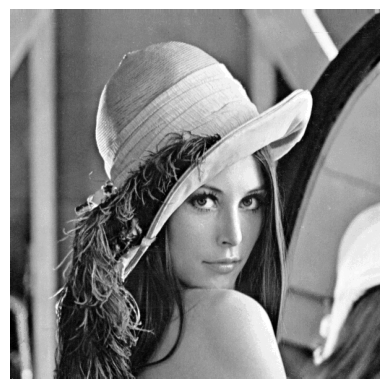

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('data/lenna.png', cv2.IMREAD_GRAYSCALE)

print(f"Image dimensions: {img.shape}")

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

Number of 8x8 blocks: 4096
Total number of pixels in 1D representation: 262144


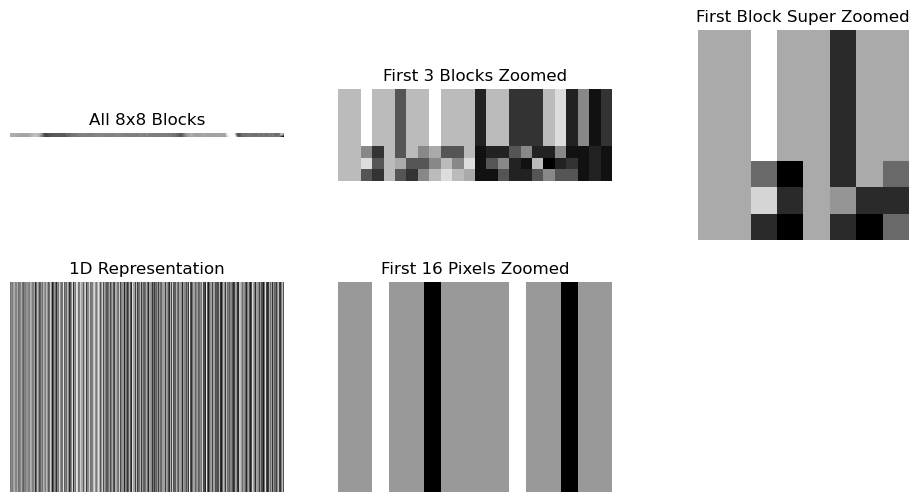

In [6]:
import numpy as np

def block_divide(img, block_size):
    h, w = img.shape
    blocks = [img[i:i+block_size, j:j+block_size] 
              for i in range(0, h, block_size) 
              for j in range(0, w, block_size)]
    return np.array(blocks)

blocks_8x8 = block_divide(img, 8)

print(f"Number of 8x8 blocks: {len(blocks_8x8)}")

blocks_strip = np.hstack(blocks_8x8[:len(blocks_8x8)//(img.shape[0]//8)])

blocks_1d = np.hstack([b.flatten().reshape(1, -1) for b in blocks_8x8])

print(f"Total number of pixels in 1D representation: {blocks_1d.size}")

plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(blocks_strip, cmap='gray')
plt.axis('off')
plt.title("All 8x8 Blocks")

plt.subplot(2, 3, 2)
plt.imshow(np.hstack(blocks_8x8[:3]), cmap='gray')
plt.axis('off')
plt.title("First 3 Blocks Zoomed")

plt.subplot(2, 3, 3)
plt.imshow(np.kron(blocks_8x8[0], np.ones((8, 8))), cmap='gray')
plt.axis('off')
plt.title("First Block Super Zoomed")

plt.subplot(2, 3, 4)
plt.imshow(blocks_1d, cmap='gray', aspect='auto')
plt.axis('off')
plt.title("1D Representation")

plt.subplot(2, 3, 5)
plt.imshow(blocks_1d[:, :16], cmap='gray', aspect='auto')
plt.axis('off')
plt.title("First 16 Pixels Zoomed")

plt.show()

In [7]:
def dct_1d(N):
    dct_mat = np.zeros((N, N))
    for k in range(N):
        for n in range(N):
            if k == 0:
                dct_mat[k, n] = np.sqrt(1 / N)
            else:
                dct_mat[k, n] = np.sqrt(2 / N) * np.cos(np.pi * (2 * n + 1) * k / (2 * N))
    return dct_mat

def dct2_basis(B):
    dct1 = dct_1d(B)
    return np.kron(dct1, dct1)

def omp(D, x, sparsity):
    residual = x.copy()
    used_atoms = []
    alpha = np.zeros(D.shape[1])

    for _ in range(sparsity):
        correlations = D.T @ residual
        atom_index = np.argmax(np.abs(correlations))
        used_atoms.append(atom_index)

        D_used = D[:, used_atoms]
        alpha_used, _, _, _ = np.linalg.lstsq(D_used, x, rcond=None)

        residual = x - D_used @ alpha_used

        if np.linalg.norm(residual) < 1e-6:
            break

    for j, idx in enumerate(used_atoms):
        alpha[idx] = alpha_used[j]

    return alpha

PSNR: 14.90
SSIM: 0.6730


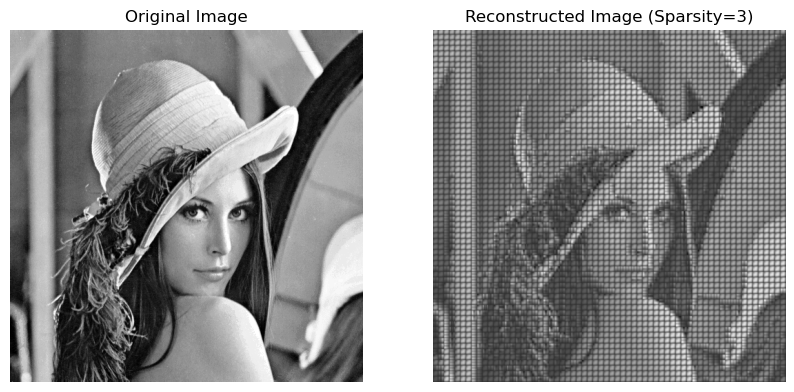

In [10]:
def reconstruct_image(blocks, D, sparsity, block_size, img_shape):
    reconstructed_blocks = np.array([D @ omp(D, block.flatten(), sparsity) 
                                     for block in blocks])
    reconstructed_blocks = reconstructed_blocks.reshape(blocks.shape)

    reconstructed_img = np.zeros(img_shape)
    idx = 0
    for i in range(0, img_shape[0], block_size):
        for j in range(0, img_shape[1], block_size):
            reconstructed_img[i:i+block_size, j:j+block_size] = reconstructed_blocks[idx].reshape((block_size, block_size))
            idx += 1

    return reconstructed_img

def mse(img1, img2):
    return np.mean((img1 - img2) ** 2)

def psnr(img1, img2):
    mse_val = mse(img1, img2)
    return 10 * np.log10(255**2 / mse_val) if mse_val > 0 else float('inf')

def ssim(img1, img2):
    mu_x, mu_y = np.mean(img1), np.mean(img2)
    sigma_x, sigma_y = np.var(img1), np.var(img2)
    sigma_xy = np.mean((img1 - mu_x) * (img2 - mu_y))

    c1, c2 = 1e-4, 9e-4
    return ((2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)) / ((mu_x**2 + mu_y**2 + c1) * (sigma_x + sigma_y + c2))

block_size = 8
D = dct2_basis(block_size)
sparsity = 3

reconstructed_img = reconstruct_image(blocks_8x8, D, sparsity, block_size, img.shape)

psnr_value = psnr(img, reconstructed_img)
ssim_value = ssim(img, reconstructed_img)

print(f"PSNR: {psnr_value:.2f}")
print(f"SSIM: {ssim_value:.4f}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img, cmap='gray')
plt.axis('off')
plt.title(f"Reconstructed Image (Sparsity={sparsity})")

plt.show()